In [1]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import seaborn as sns 
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import pandas as pd
from multiprocessing import Pool, cpu_count
import numpy as np

sns.set_style('whitegrid')

In [2]:
benchmark_name_dict = {
    "medmcqa": "MedMCQA",
    "medqa_test": "MedQA",
    "clinical_knowledge": "MMLU - clinical knowledge",
    "professional_medicine": "MMLU - professional medicine",
    "anatomy": "MMLU - anatomy",
    "medexpqa": "MedExpQA",
}

model_name_dict = {
    "Qwen2.5-3B-Instruct": "Q3B",
    "Qwen2.5-7B-Instruct": "Q7B",
    "NACC-3B": "LUNAR-OS-SCE",
    "NACC-3B-OS": "LUNAR-SCE",
    "NACC-3B-SCE": "LUNAR-OS",
    "NACC-3B-OS-SCE": "LUNAR",
}


def load_answers(dir_path, dataset_name):
    # load all parquet files from the directory, stack them into a pandas datafame
    # this only reads the participant ID, ground trush answer and the prediction,
    # which is significantly (about 100x) faster than loading the whole dataframe.
    # Loading everything is very slow because there are extremely long strings in some columns

    fpaths = list(dir_path.rglob("*.parquet"))

    dfs = []

    cols_to_read = [
        "ID",
        "ground_truth",
        "prediction",
        "generated_text",
        "finish_reason",
    ]

    for fpath in tqdm(fpaths):
        model = fpath.parent.name.split("-", 3)[-1]
        benchmark = fpath.parent.parent.name.split("_", 1)[-1].upper()

        if benchmark not in ['COG','ETPR']:
            continue

        df = pd.read_parquet(fpath, columns=cols_to_read)

        df = df.assign(model=model, benchmark=benchmark)

        df["correct"] = (df["ground_truth"] == df["prediction"]).astype(int)

        df["dataset"] = dataset_name

        dfs.append(df)

    df = pd.concat(dfs)

    df["model"] = df["model"].replace(model_name_dict)

    # make these columns Categorical
    group_cols = ["benchmark", "model", "prediction", "ground_truth"]
    for col in group_cols:
        df[col] = pd.Categorical(df[col])

    return df

In [3]:
nifd_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/NIFD')
nacc_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/NACC')
adni_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/ADNI')
adni_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/PPMI')
brainlat_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/brainlat')

In [4]:
nifd = load_answers(nifd_path,dataset_name='NIFD')
adni = load_answers(adni_path,dataset_name='ADNI')
nacc = load_answers(nacc_path,dataset_name='NACC')
ppmi = load_answers(nacc_path,dataset_name='PPMI')
brainlat = load_answers(nacc_path,dataset_name='BrainLat')

  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 72/72 [00:27<00:00,  2.61it/s]


In [6]:
model_order = [
    "Q3B",
    # "LUNAR-OS-SCE",
    # "LUNAR-SCE",
    # "LUNAR-OS",
    "LUNAR",
    "Q7B",
    # "NACC-7B-OS",
    # "NACC-7B-OS-SCE",
]

In [7]:
df = pd.concat([nifd,adni,nacc,ppmi,brainlat])

df = df[['dataset','benchmark','model','ID','generated_text','finish_reason','correct',]]

# only keep models we care about
df = df[df['model'].isin(model_order)]

In [9]:
df.shape

(2803620, 7)

In [8]:
df.sample(3)

,dataset,benchmark,model,ID,generated_text,finish_reason,correct
99183,NACC,COG,LUNAR,NACC266863,"To determine the patient's cognitive status, w...",stop,1
29906,BrainLat,COG,LUNAR,NACC311390,"Based on the information provided, the patient...",stop,1
122848,NACC,ETPR,Q7B,NACC460189,Let's break down the information step by step ...,stop,1


It looks like 20/5.6M cases fail to stop, we can probably drop those responses as invalid.

In [10]:
df['finish_reason'].value_counts()

finish_reason
stop      2803610
length         10
Name: count, dtype: int64

In [11]:
import os

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")

# Enable tokenizer parallelism explicitly
os.environ["TOKENIZERS_PARALLELISM"] = "true"

def count_tokens_fast(df, text_column, model_name="Qwen/Qwen2.5-3B-Instruct", batch_size=10000):
    """
    Fast token counting using the tokenizer's built-in parallelism
    This is typically faster than multiprocessing for this task
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    texts = df[text_column].fillna('').tolist()
    
    token_counts = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]
        encoded = tokenizer(
            batch,
            add_special_tokens=False,
            truncation=False,
            padding=False,
            return_attention_mask=False
        )
        token_counts.extend([len(ids) for ids in encoded['input_ids']])
    
    return token_counts

# Usage:
# df['token_count'] = count_tokens_fast(df, 'your_text_column')

In [195]:
ex = df
# .sample(1000000)

In [196]:
ex['token_count'] = count_tokens_fast(ex, 'generated_text',batch_size=1000)

100%|██████████| 2804/2804 [11:27<00:00,  4.08it/s]


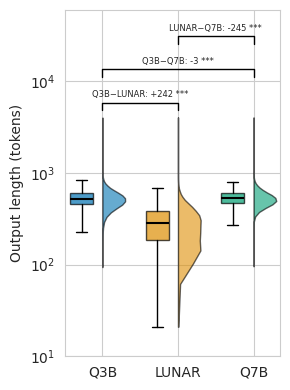


Statistical Test Results (Benjamini-Hochberg corrected):
Q3B vs LUNAR: Δ median = +242.0, p = 0.0000 (***)
Q3B vs Q7B: Δ median = -3.0, p = 0.0000 (***)
LUNAR vs Q7B: Δ median = -245.0, p = 0.0000 (***)


In [197]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Prepare data
_df = ex
_df['model'] = _df['model'].cat.remove_unused_categories()
_df = _df[_df['finish_reason'] == 'stop']

# Set up colors
palette = sns.color_palette("colorblind", n_colors=len(model_order))
color_map = {model: palette[i] for i, model in enumerate(model_order)}

# Create figure
fig, ax = plt.subplots(figsize=(3,4))

# Plot for each model
positions = np.arange(len(model_order))
violin_width = 0.6
box_width = 0.3

for i, model in enumerate(model_order):
    model_data = _df[_df['model'] == model]['token_count'].values
    color = color_map[model]
    
    # Create half violin (right side only)
    parts = ax.violinplot(
        [model_data],
        positions=[i],
        widths=violin_width,
        showmeans=False,
        showextrema=False,
        showmedians=False
    )
    
    # Modify violin to show only right half and color it
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)
        
        # Get the paths and modify to show only right half
        m = np.mean(pc.get_paths()[0].vertices[:, 0])
        pc.get_paths()[0].vertices[:, 0] = np.clip(
            pc.get_paths()[0].vertices[:, 0], m, np.inf
        )
    
    # Add box plot (on the left side)
    bp = ax.boxplot(
        [model_data],
        positions=[i - violin_width/2 - box_width/2 + 0.175],
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=1.5),
        boxprops=dict(facecolor=color, edgecolor='black', alpha=0.7),
        whiskerprops=dict(color='black', linewidth=1),
        capprops=dict(color='black', linewidth=1)
    )

# Statistical testing
# Perform pairwise t-tests
models_to_compare = ['Q3B', 'LUNAR', 'Q7B']
pairs = [(models_to_compare[i], models_to_compare[j]) 
         for i in range(len(models_to_compare)) 
         for j in range(i+1, len(models_to_compare))]

p_values = []
median_diffs = []

for model1, model2 in pairs:
    data1 = _df[_df['model'] == model1]['token_count'].values
    data2 = _df[_df['model'] == model2]['token_count'].values
    
    # Two-sided t-test
    t_stat, p_val = stats.ttest_ind(data1, data2, equal_var=False)
    p_values.append(p_val)
    
    # Calculate median difference
    median1 = np.median(data1)
    median2 = np.median(data2)
    median_diff = median1 - median2
    median_diffs.append(median_diff)

# Apply Benjamini-Hochberg correction
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Add significance annotations
def get_significance_label(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

# Get positions for each model
model_positions = {model: i for i, model in enumerate(model_order)}

# Draw significance bars
y_max = ax.get_ylim()[1]
bar_height = y_max * 1.15
height_increment = 2.3

for idx, (model1, model2) in enumerate(pairs):
    if model1 in model_positions and model2 in model_positions:
        x1 = model_positions[model1]
        x2 = model_positions[model2]
        
        y = bar_height * (height_increment ** idx) 
        
        sig_label = get_significance_label(p_adjusted[idx])
        median_diff = median_diffs[idx]
        
        # Format the label with median difference and model names
        # Shows which direction: model1 - model2
        if sig_label != 'ns':
            label = f"{model1}−{model2}: {median_diff:+.0f} {sig_label}"
        else:
            label = f"{model1}−{model2}: {median_diff:+.0f} {sig_label}"
        
        # Draw the bar
        ax.plot([x1, x1, x2, x2], [y, y*1.2, y*1.2, y], 
                linewidth=1, color='black')
        
        # Add the significance label with white background and rounded corners
        ax.text((x1 + x2) / 2, y*1.3, label, 
                ha='center', va='bottom', fontsize=6,
        )
                # bbox=dict(facecolor='white', edgecolor='none', pad=0, alpha=0,boxstyle='round,pad=0.3'))

# Customize plot
ax.set_xticks(positions)
ax.set_xticklabels(model_order, rotation=0, ha='center')
ax.set_ylabel('Output length (tokens)', fontsize=10)
ax.set_yscale('log')
ax.grid(axis='y', alpha=1, linestyle='-')
ax.set_xlim(-0.5, len(model_order) - 0.65)

# Adjust y-limit to accommodate significance bars
ax.set_ylim(10, 6e4)

plt.tight_layout()
plt.show()

# Print results
print("\nStatistical Test Results (Benjamini-Hochberg corrected):")
for idx, (model1, model2) in enumerate(pairs):
    print(f"{model1} vs {model2}: Δ median = {median_diffs[idx]:+.1f}, p = {p_adjusted[idx]:.4f} ({get_significance_label(p_adjusted[idx])})")

In [198]:
fig.savefig('../figures/output_length_all.pdf',bbox_inches='tight')

In [ ]:
# Make an ANOVA and then the tukey test for posthoc comparison between pairs

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Polygon
from scipy import stats

def create_ridgeplot(df, model_order=None, dataset_order=None, figsize=None):
    """
    Create a ridgeplot showing token count distributions
    Rows: datasets, Columns: benchmarks, within each: models as ridges
    
    Parameters:
    - df: DataFrame with columns 'dataset', 'benchmark', 'model', 'token_count'
    - model_order: List of models in desired order. Only these models will be plotted.
    - dataset_order: List of datasets in desired order. Only these datasets will be plotted.
    - figsize: Tuple (width, height). If None, width is set to 7 inches.
    """
    # Get unique values
    if dataset_order is None:
        datasets = sorted(df['dataset'].unique())
    else:
        datasets = dataset_order
    
    benchmarks = sorted(df['benchmark'].unique())
    
    # Use provided model order or fall back to sorted unique
    if model_order is None:
        models = sorted(df['model'].unique())
    else:
        models = model_order
    
    # Filter dataframe to only include models and datasets in the orders
    df = df[df['model'].isin(models) & df['dataset'].isin(datasets)]
    
    # Set figure size
    if figsize is None:
        n_rows = len(datasets)
        height = max(4, n_rows * 3)
        figsize = (7, height)
    
    # Create color palette
    colors = sns.color_palette("colorblind", len(models))
    model_colors = dict(zip(models, colors))
    
    # Create figure
    n_rows = len(datasets)
    n_cols = len(benchmarks)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, 
                             sharex=True, sharey=True, layout='constrained')
    
    # Handle single row/column cases
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Plot for each dataset-benchmark combination
    for i, dataset in enumerate(datasets):
        for j, benchmark in enumerate(benchmarks):
            ax = axes[i, j]
            
            # Filter data
            subset = df[(df['dataset'] == dataset) & 
                       (df['benchmark'] == benchmark)]
            
            if len(subset) == 0:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                       transform=ax.transAxes, fontsize=12, color='gray')
            else:
                # Calculate distributions for each model
                y_step = 1.0
                
                for k, model in enumerate(models):
                    model_data = subset[subset['model'] == model]['token_count'].values
                    
                    if len(model_data) == 0:
                        continue
                    
                    # Calculate KDE
                    try:
                        kde = stats.gaussian_kde(model_data)
                        x_range = np.linspace(model_data.min(), model_data.max(), 200)
                        density = kde(x_range)
                        
                        # Normalize density for better visualization
                        density = density / density.max() * 0.8
                        
                        # Create polygon for filled area
                        y_base = k * y_step
                        vertices = [(x_range[0], y_base)]
                        for x, d in zip(x_range, density):
                            vertices.append((x, y_base + d))
                        vertices.append((x_range[-1], y_base))
                        
                        # Draw filled polygon
                        poly = Polygon(vertices, facecolor=model_colors[model], 
                                     edgecolor='black', alpha=0.7, linewidth=1)
                        ax.add_patch(poly)
                        
                        # Add median marker
                        median_val = np.median(model_data)
                        median_density = kde(median_val)[0] / kde(x_range).max() * 0.8
                        ax.plot([median_val, median_val], [y_base, y_base + median_density], 
                               'k-', linewidth=1, zorder=10)
                        ax.text(median_val + 10, y_base + 0.05, 
                               f'{median_val:.0f}', 
                               ha='left', va='bottom', fontsize=7)
                    
                    except:
                        # If KDE fails (e.g., too few points), skip
                        continue
                
                # Set limits
                if len(subset) > 0:
                    all_tokens = subset['token_count'].values
                    ax.set_xlim(all_tokens.min() * 0.95, all_tokens.max() * 1.05)
            
            # Set y-axis with model names
            ax.set_yticks([k * y_step for k in range(len(models))])
            ax.set_yticklabels(models, va='bottom')
            ax.set_ylim(-0.5, len(models) * y_step)
            
            # Add grid aligned with bottom of each KDE
            ax.set_axisbelow(True)
            ax.yaxis.grid(True, alpha=1)
            ax.xaxis.grid(True, alpha=1)
            
            # Add titles
            if i == 0:
                ax.set_title(f'{benchmark}', fontsize=12, pad=10)
            if j == n_cols - 1:
                # Add dataset label to the right of the rightmost panel
                ax2 = ax.twinx()
                ax2.set_yticks([])
                ax2.set_ylabel(f'{dataset}', fontsize=12, rotation=270, labelpad=15)
            if i == n_rows - 1:
                ax.set_xlabel('Token Count', fontsize=10)

    return fig

# Example usage:
# fig = create_ridgeplot(df, model_order=['model1', 'model2', 'model3'], 
#                        dataset_order=['dataset1', 'dataset2'])

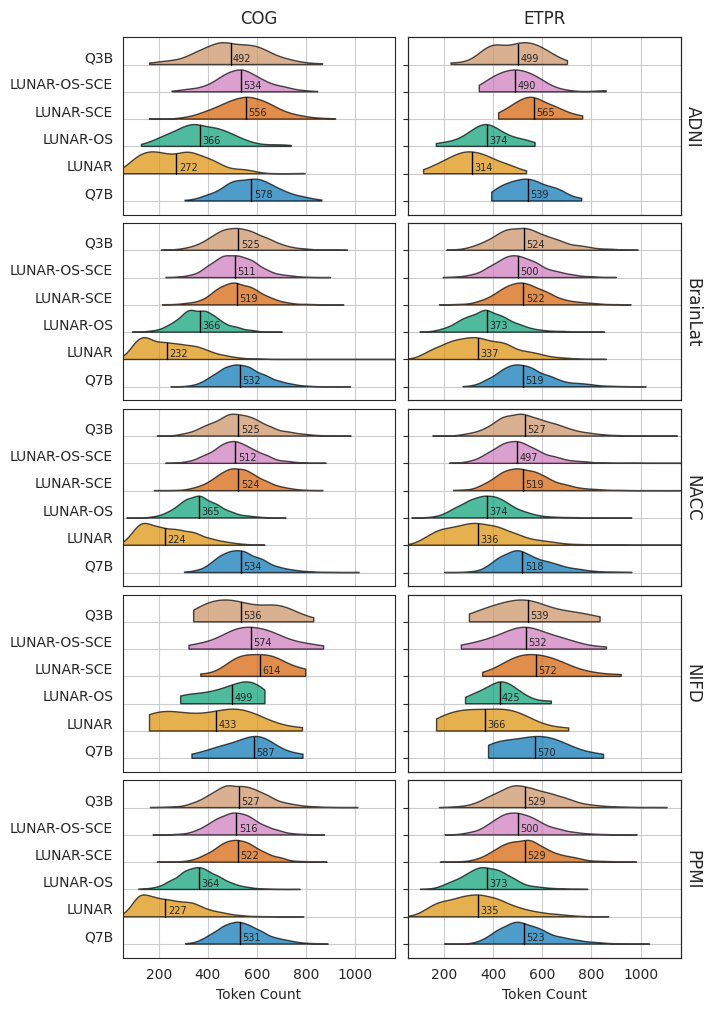

In [82]:
fig = create_ridgeplot(ex,model_order=model_order[::-1],figsize=(7,10))

In [83]:
fig.savefig('../figures/token_counts_ridgeplot.pdf',bbox_inches='tight')

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def create_boxplot(df, model_order=None, dataset_order=None, figsize=None):
    """
    Create a boxplot showing token count distributions
    Rows: datasets, Columns: benchmarks, within each: models as boxes
    
    Parameters:
    - df: DataFrame with columns 'dataset', 'benchmark', 'model', 'token_count'
    - model_order: List of models in desired order. Only these models will be plotted.
    - dataset_order: List of datasets in desired order. Only these datasets will be plotted.
    - figsize: Tuple (width, height). If None, width is set to 7 inches.
    """
    # Get unique values
    if dataset_order is None:
        datasets = sorted(df['dataset'].unique())
    else:
        datasets = dataset_order
    
    benchmarks = sorted(df['benchmark'].unique())
    
    # Use provided model order or fall back to sorted unique
    if model_order is None:
        models = sorted(df['model'].unique())
    else:
        models = model_order
    
    # Filter dataframe to only include models and datasets in the orders
    df = df[df['model'].isin(models) & df['dataset'].isin(datasets)]
    
    # Set figure size
    if figsize is None:
        n_rows = len(datasets)
        height = max(4, n_rows * 3)
        figsize = (7, height)
    
    # Create color palette
    colors = sns.color_palette("colorblind", len(models))
    model_colors = dict(zip(models, colors))
    
    # Create figure
    n_rows = len(datasets)
    n_cols = len(benchmarks)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, 
                             sharex=True, sharey=True, layout='constrained')
    
    # Handle single row/column cases
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Plot for each dataset-benchmark combination
    for i, dataset in enumerate(datasets):
        for j, benchmark in enumerate(benchmarks):
            ax = axes[i, j]
            
            # Filter data
            subset = df[(df['dataset'] == dataset) & 
                       (df['benchmark'] == benchmark)]
            
            if len(subset) == 0:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                       transform=ax.transAxes, fontsize=12, color='gray')
            else:
                # Prepare data for boxplot
                box_data = []
                box_positions = []
                box_colors = []
                
                for k, model in enumerate(models):
                    model_data = subset[subset['model'] == model]['token_count'].values
                    
                    if len(model_data) > 0:
                        box_data.append(model_data)
                        box_positions.append(k)
                        box_colors.append(model_colors[model])
                
                # Create boxplot
                if box_data:
                    bp = ax.boxplot(box_data, positions=box_positions, widths=0.6,
                                   patch_artist=True, showfliers=True,
                                   boxprops=dict(linewidth=1),
                                   whiskerprops=dict(linewidth=1),
                                   capprops=dict(linewidth=1),
                                   medianprops=dict(linewidth=1, color='black'),
                                   flierprops=dict(marker='o', markersize=3, alpha=0.5))
                    
                    # Color the boxes
                    for patch, color in zip(bp['boxes'], box_colors):
                        patch.set_facecolor(color)
                        patch.set_alpha(0.7)
                    
                    # Add median annotations
                    for k, model in enumerate(models):
                        model_data = subset[subset['model'] == model]['token_count'].values
                        
                        if len(model_data) > 0:
                            median_val = np.median(model_data)
                            q3 = np.percentile(model_data, 75)
                            # Position text just above upper quartile
                            y_range = subset['token_count'].max() - subset['token_count'].min()
                            offset = y_range * 0.01  # Small offset above Q3
                            offset=15
                            ax.text(k, q3 + offset, f'{median_val:.0f}',
                                   ha='center', va='bottom', fontsize=6,
                                   bbox=dict(boxstyle='round,pad=0.1', 
                                           facecolor='white', edgecolor='none'))
                
                # Set limits with extra padding to ensure all data is visible
                if len(subset) > 0:
                    y_min = subset['token_count'].min()
                    y_max = subset['token_count'].max()
                    y_range = y_max - y_min
                    ax.set_ylim(
                        # bottom=y_min - y_range * 0.1,
                        bottom=0,
                               top=y_max + y_range * 0.1)
            
            # Set y-axis with model names
            ax.set_xticks(range(len(models)))
            ax.set_xticklabels(models, rotation=90, ha='center', va='top')
            
            # Add grid
            ax.set_axisbelow(True)
            ax.yaxis.grid(True, alpha=1)
            ax.xaxis.grid(True, alpha=1)
            
            # Add titles
            if i == 0:
                ax.set_title(f'{benchmark}', fontsize=12, pad=10)
            if j == n_cols - 1:
                # Add dataset label to the right of the rightmost panel
                ax2 = ax.twinx()
                ax2.set_yticks([])
                ax2.set_ylabel(f'{dataset}', fontsize=12, rotation=270, labelpad=15)
            # if i == n_rows - 1:
                # ax.set_xlabel('Model', fontsize=10)
            if j == 0:
                ax.set_ylabel('Token Count', fontsize=10)
    
    return fig

# Example usage:
# fig = create_boxplot(df, model_order=['model1', 'model2', 'model3'], 
#                      dataset_order=['dataset1', 'dataset2'])

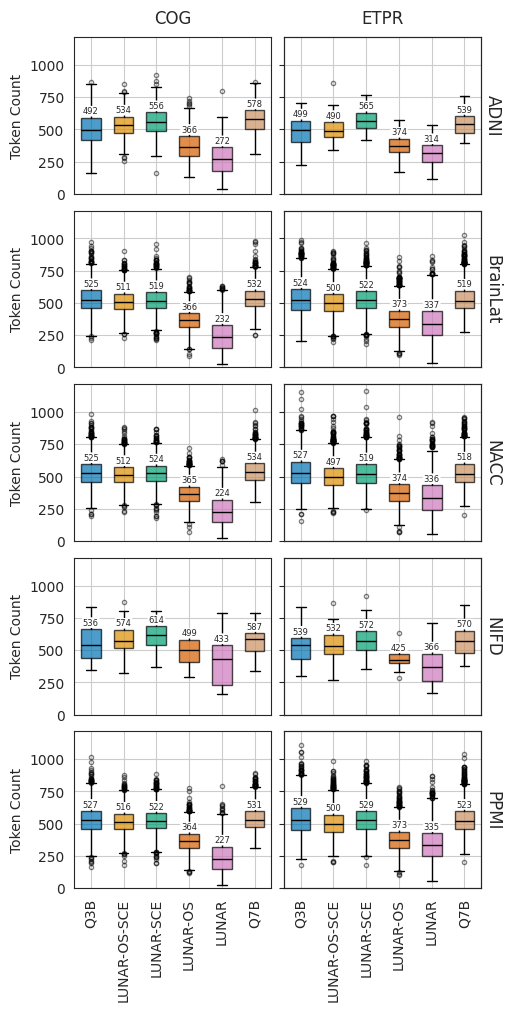

In [85]:
fig2 = create_boxplot(ex,model_order=model_order,figsize=(5,10))

In [87]:
fig2.savefig('../figures/token_counts_boxplot.pdf',bbox_inches='tight')